# Tutorial: working with a simulated Argus survey

This tutorial works through the v5.4 5-year survey run from its visit store, the product users receive. It starts
with depth over time and across the sky, and ends with simulated light curves of variable stars, supernovae, and
kilonova models.

The steps show:

- What the visit store holds and how to open it from a local directory or an S3 bucket.
- How to read depth night by night and turn inverse variance into a limiting magnitude.
- How to read the tile depth maps for the whole survey and for each half-year, and the nights each tile was seen.
- How to list every exposure of a sky position and see why a night has no data.
- How to inject light-curve models, bin them and measure what Argus would recover.

To run it:

- Use the ArgusSim environment (`.venv` in the ArgusSim checkout) with Jupyter. ArgusSim installs sncosmo. Step 15
  also needs redback (`pip install redback`).
- Set `STORE` in the first code cell to the visit store of the v5.4 5-year run: a local directory (here
  `~/argussim_runs/canonical-5yr-2028-store`), or the S3 URI
  `s3://schmidt-observatory-system/argus/sim/argsim_5yr_beta_rho_uniform_v5.4/`, in which case pass the bucket's credentials or endpoint as `storage_options`.


For how a single exposure's depth is computed from the sky background and instrument models, see
`tutorial_depth_calculation.ipynb`.

In [1]:
# 'g' is the Argus beta band.
# The visit store of the v5.4 run: a local directory, or the S3 URI
# s3://schmidt-observatory-system/argus/sim/argsim_5yr_beta_rho_uniform_v5.4/
STORE = "~/argussim_runs/canonical-5yr-2028-store"

import json
import os
import time
import warnings

import logging
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.table import Table
from astropy.time import Time

warnings.filterwarnings("ignore")
logging.getLogger("argus_sim").setLevel(logging.WARNING)

plt.rcParams.update({"figure.figsize": (10, 4), "figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
BAND_COLOR = {"g": "#2a78d6", "rho": "#eb6834"}
T_START = time.time()

## Step 1. Open the visit store

The survey simulator writes one record per 16-minute pointing (a ratchet in the code), listing every (sky tile, OTA) pair it covered, with the background noise of one exposure and the pointing's time, seeing and transparency. The visit store holds the same
records sorted by sky tile, plus the survey's nightly summaries and tile depth
maps. `SurveyRun` reads it. For a store in S3, pass the URI and, as `storage_options`, the keyword arguments of
`pyarrow.fs.S3FileSystem` (region, credentials or endpoint), for example
`SurveyRun("s3://schmidt-observatory-system/argus/sim/argsim_5yr_beta_rho_uniform_v5.4/", storage_options={...})`.

In [4]:
from argus_sim.lightcurve import SurveyRun, bin_lightcurve

run = SurveyRun(STORE)
print(run)
plan = run.meta["plan"]
print(f"plan: {plan['start']} to {plan['end']}, {plan['n_nights']:,} nights available, {plan['n_kept_nights']:,} observed")
print("bands:", run.bands)
print("periods:", run.periods)

manifest = json.loads(run.store.read_bytes("manifest.json"))
sizes = {}
for f in manifest["files"]:
    key = f["path"].split("/")[0] + ("/" if "/" in f["path"] else "")
    sizes[key] = sizes.get(key, 0) + f["bytes"]
for key, b in sorted(sizes.items(), key=lambda kv: -kv[1]):
    print(f"{key:<16} {b / 1e6:10.1f} MB")
    
print(f"{'total':<16} {sum(sizes.values()) / 1e9:10.2f} GB")
print(f"{run.meta['pairs_bytes'] / run.meta['n_pair_rows']:.2f} bytes per (tile, OTA) record")

SurveyRun('/home/user/argussim_runs/canonical-5yr-2028-store': 43397 ratchets, 116695 tiles, 2,526,741,344 pair rows, bands ['g', 'rho'])
plan: 2028-01-01T00:00:00 to 2033-01-01T00:00:00, 1,827 nights available, 1,253 observed
bands: ['g', 'rho']
periods: ['2028H1', '2028H2', '2029H1', '2029H2', '2030H1', '2030H2', '2031H1', '2031H2', '2032H1', '2032H2', 'all']
pairs/               6646.8 MB
depth.parquet          70.5 MB
ratchets.npz            7.6 MB
tiles.npz               0.4 MB
nights.parquet          0.2 MB
layout.npz              0.1 MB
index.json              0.1 MB
total                  6.73 GB
2.63 bytes per (tile, OTA) record


| file | contains |
|---|---|
| `index.json` | format, band zero points, the survey plan, settings, the whole-survey depth summary, and how each stored or recomputed column is defined |
| `pairs/shard_NNNN.parquet` | the (tile, OTA) records sorted by tile: ratchet, OTA, whether the OTA covers the whole tile, and the background noise (16 bits) |
| `ratchets.npz`, `layout.npz`, `tiles.npz` | per-pointing times, conditions and sky rotations; the OTA frames; where each tile's records are |
| `depth.parquet` | tile depth maps per band, for the whole survey and each half-year |
| `nights.parquet` | depth, area, Moon and band-alternation statistics per night and band |
| `manifest.json` | every file with its size and SHA-256, for checking a download (or upload)|

The store holds 2,526,741,344 (tile, OTA) records in 116,695 sky tiles, in 6.73 GB, about
2.63 bytes per record. The survey planned 1,827 nights and observed on 1,253, for an average weather fraction of about 68%. To keep the store small, airmass, throughput, field angle and covered area are recomputed by each query from the pointing's sky rotation and the OTA's field.

## Step 2. Depth night by night

`run.nights()` has one row per night and band. `median_limmag` is the median 5σ limiting magnitude of all the night's
exposures stacked, over the sky pixels seen that night. `n_fast_ratchets` counts the pointings taken in fast mode (1-s
frames), because the Moon was more than 96% illuminated.

1253 nights with data; columns: night, mjd_min, mjd_max, band, n_minipix, area_deg2, median_limmag, p16_limmag, p84_limmag, median_n_obs, mean_n_obs, median_n_obs_base, ...


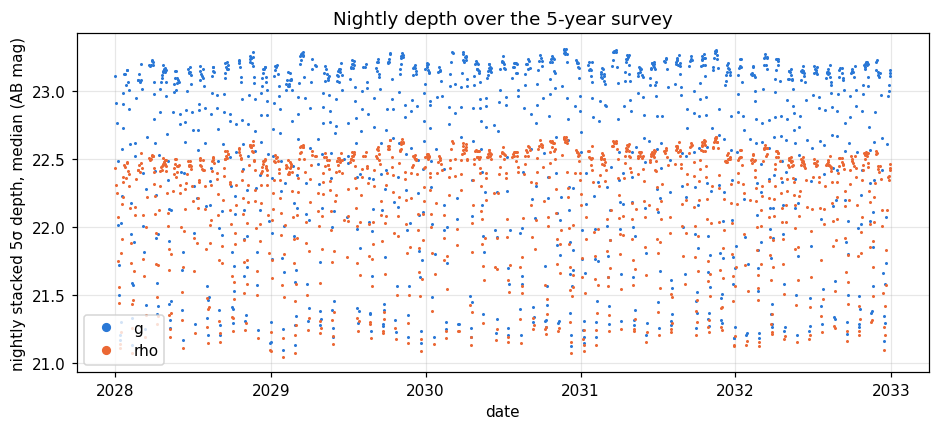

g: median nightly depth 22.87 mag; 22.98 on dark nights, 21.30 on nights mostly in 1-s frames (154 nights)


In [5]:
ns = run.nights().to_pandas()
ns["date"] = Time(ns["mjd_min"].to_numpy(), format="mjd").datetime
print(f"{ns['night'].nunique()} nights with data; columns: {', '.join(ns.columns[:12])}, ...")

fig, ax = plt.subplots()
for b in ("g", "rho"):
    x = ns[ns["band"] == b]
    ax.plot(x["date"], x["median_limmag"], ".", ms=2, color=BAND_COLOR[b], label=b)
ax.set_xlabel("date"); ax.set_ylabel("nightly stacked 5σ depth, median (AB mag)")
ax.set_title("Nightly depth over the 5-year survey"); ax.legend(markerscale=5)
plt.show()

g = ns[ns["band"] == "g"]
fast = g["n_fast_ratchets"] > 0.5 * g["n_ratchets"]
print(f"g: median nightly depth {g['median_limmag'].median():.2f} mag; "
      f"{g.loc[~fast, 'median_limmag'].median():.2f} on dark nights, "
      f"{g.loc[fast, 'median_limmag'].median():.2f} on nights mostly in 1-s frames ({fast.sum()} nights)")

The g/beta depth of a night's stack has a median of 22.87 mag across all conditions.

The same table describes the band alternation within each night (these columns repeat for both bands of a night):

In [6]:
print(g[["swap_single_band", "both_bands_in_night", "same_band_looks_ge2"]].describe().loc[["mean", "50%"]].round(3))

      swap_single_band  both_bands_in_night  same_band_looks_ge2
mean             0.798                0.959                 0.05
50%              0.799                0.959                 0.05


`both_bands_in_night` is the fraction of positions seen in both bands within a night. Its median
is 0.959. `swap_single_band` is how often a position seen in one band in one pointing is seen in the other
band in the next, which is roughly how often a position gets both bands within about 30 minutes.

## Step 3. From inverse variance to limiting magnitude

Depths are built from inverse variance, which adds over exposures: the total for five years is the sum over every
exposure. For one exposure, the weight is $T^2/\sigma_\mathrm{bkg}^2$, with $T$ the full-system throughput and
$\sigma_\mathrm{bkg}$ the background noise in electrons, so

$$I = \sum_i n_i\,\frac{T_i^2}{\sigma_{\mathrm{bkg},i}^2}.$$

A source at the 5σ threshold of the stack gives $5/\sqrt{I}$ electrons per exposure above the atmosphere. Dividing
by the mean exposure time and the detector QE gives a photon rate, and the band's AB zero point turns that into a
magnitude:

$$\dot n_{5\sigma} = \frac{5}{\sqrt{I}}\,\frac{N}{t_\mathrm{tot}\,\mathrm{QE}_b},\qquad
m_{5\sigma} = -2.5\log_{10}\frac{\dot n_{5\sigma}}{\mathrm{zp}_b},$$

where $N$ counts exposures and $t_\mathrm{tot}$ is their summed exposure time. The cell below writes this out with the
store's zero points and checks it against the light-curve API's `limit_mag` for the same exposure.

In [9]:
ZP = run.zeropoints

def limmag(I, n_exp, t_tot, band, nsigma=5.0):
    rate = nsigma / np.sqrt(I) * n_exp / t_tot / ZP[band]["band_qe"]   # photons/s above the atmosphere
    return -2.5 * np.log10(rate / ZP[band]["zp_photons_per_sec"])

# one 60-s g exposure with T = 0.55 and sigma_bkg = 40 e-
one = Table({"band": ["g"], "exptime_s": [60.0], "n_frames": [1], "sigma_bkg_e": [40.0], "throughput": [0.55]})
print(f"formula {limmag(0.55**2 / 40**2, 1, 60.0, 'g'):.3f} mag; "
      f"run.limit_mag without source noise {run.limit_mag(one, source_poisson=False)[0]:.3f} mag")
for n in (10, 100, 1000):
    print(f"{n:5d}x exposures: {limmag(n * 0.55**2 / 40**2, n, n * 60.0, 'g'):.2f} mag")

formula 20.048 mag; run.limit_mag without source noise 20.048 mag
   10x exposures: 21.30 mag
  100x exposures: 22.55 mag
 1000x exposures: 23.80 mag


A single 60-s beta exposure with throughput 0.55 and 40 e⁻ of background noise reaches
20.05 mag at 5σ, and `limit_mag` agrees. Stacking N equal exposures multiplies $I$ by N and deepens the limit by
$1.25\log_{10} N$ mag: 1.25 mag per factor of ten.

## Step 4. A 5-year depth map of the sky

The depth maps sum $I$, the exposure count and the exposure time over every 28″ sky pixel (minipix) of every 0.5°
tile, apply the formula above per minipix and keep, per tile, the median over the minipixes the tile owns (tiles
overlap by 28″, and ownership counts each sky position once). `run.depth_map(band, "all")` returns that map for the
whole survey, one row per tile.

In [10]:
dm = {b: run.depth_map(b, "all") for b in run.bands}
for b in run.bands:
    d = dm[b]
    ok = np.isfinite(d["limmag"])
    full = np.sum(d["covered_fraction"] > 0.99)
    print(f"{b:>4}: {len(d):,} tiles, {full:,} fully covered, median tile depth {np.median(d['limmag'][ok]):.2f} mag "
          f"(whole-survey median over minipixes: {run.meta['span'][b]['median_limmag']:.2f})")

   g: 116,695 tiles, 115,927 fully covered, median tile depth 26.07 mag (whole-survey median over minipixes: 26.07)
 rho: 116,695 tiles, 115,927 fully covered, median tile depth 25.98 mag (whole-survey median over minipixes: 25.98)


116,695 tiles have records in g/beta. Their median depth is 26.07 mag in beta and 25.98 mag in rho, the
same as the medians over all minipixes in the survey summary (`run.meta["span"]`). 115,927 of the beta tiles are
fully covered, and the rest lie on the edges of the footprint.

The map below shows the tile depths on the sky, one point per tile, in an equatorial Mollweide projection.

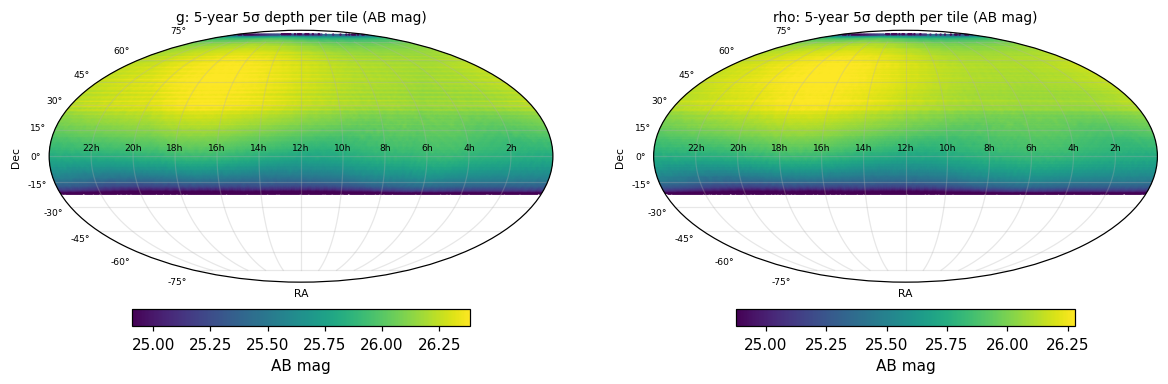

   g: per-tile depth 2-98% 24.91-26.39 mag; deepest at Dec +33.3°
 rho: per-tile depth 2-98% 24.88-26.28 mag; deepest at Dec +47.6°


In [11]:
def sky(ax, table, value, title, label, **kw):
    x = -np.radians(np.asarray(table["ra"]) - 180.0)      # RA 12h at the centre, increasing to the left
    sc = ax.scatter(x, np.radians(table["dec"]), c=value, s=0.3, **kw)
    ax.set_title(title, fontsize=9)
    ax.set_xticklabels([f"{h}h" for h in (22, 20, 18, 16, 14, 12, 10, 8, 6, 4, 2)], fontsize=6)
    ax.tick_params(axis="y", labelsize=6)
    ax.set_xlabel("RA", fontsize=7); ax.set_ylabel("Dec", fontsize=7)
    return sc

fig, axes = plt.subplots(1, 2, figsize=(13, 4), subplot_kw={"projection": "mollweide"})
for ax, b in zip(axes, run.bands):
    d = dm[b][np.isfinite(dm[b]["limmag"])]
    sc = sky(ax, d, d["limmag"], f"{b}: 5-year 5σ depth per tile (AB mag)", "AB mag", cmap="viridis",
             vmin=np.percentile(d["limmag"], 2), vmax=np.percentile(d["limmag"], 98))
    fig.colorbar(sc, ax=ax, orientation="horizontal", fraction=0.05, pad=0.08, label="AB mag")
plt.show()

for b in run.bands:
    d = dm[b][np.isfinite(dm[b]["limmag"])]
    print(f"{b:>4}: per-tile depth 2-98% {np.percentile(d['limmag'], 2):.2f}-{np.percentile(d['limmag'], 98):.2f} mag; "
          f"deepest at Dec {d['dec'][np.argmax(d['limmag'])]:+.1f}°")

Per-tile depths span 24.91-26.39 mag in beta (2nd to 98th percentile) in the v5.4 run. The deepest tiles lie
near Dec +33.3°, close to the site's latitude, where the sky passes nearest the zenith and stays in the
footprint longest. Depth falls toward the northern and southern edges of the footprint. The east-west trend follows the seasonal seeing and weather.

**Try it.** Plot `dm["g"]["n_slots_60"]` instead of the depth to see how many 60-s slots each tile got. The pattern
should follow the depth map, with the most slots near the site's latitude.

## Step 5. Depth in each half-year

The store also holds a depth map for each half-year of the survey (January to June and July to December), labelled
in `run.periods`. The ten g/beta maps below share one colour scale.

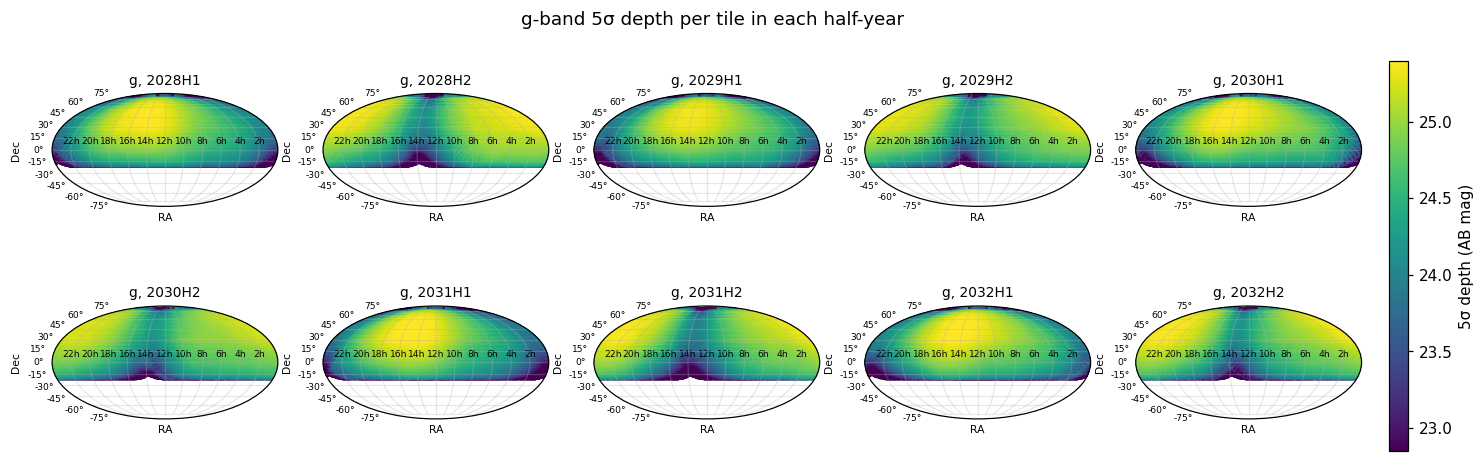

2028H1: 116,329 tiles, median depth 24.63 mag, median 82 nights per tile
2028H2: 116,296 tiles, median depth 24.82 mag, median 88 nights per tile
2029H1: 116,270 tiles, median depth 24.62 mag, median 81 nights per tile
2029H2: 116,322 tiles, median depth 24.73 mag, median 85 nights per tile
2030H1: 116,260 tiles, median depth 24.72 mag, median 74 nights per tile
2030H2: 116,318 tiles, median depth 24.72 mag, median 83 nights per tile
2031H1: 116,314 tiles, median depth 24.59 mag, median 84 nights per tile
2031H2: 116,322 tiles, median depth 24.71 mag, median 90 nights per tile
2032H1: 116,283 tiles, median depth 24.69 mag, median 86 nights per tile
2032H2: 116,317 tiles, median depth 24.75 mag, median 87 nights per tile
2028H1: RA hours within 0.25 mag of the deepest hour: [10, 11, 12, 13, 14, 15, 16, 17, 18]
2028H2: RA hours within 0.25 mag of the deepest hour: [0, 1, 2, 3, 4, 5, 6, 7, 20, 21, 22, 23]


In [12]:
halves = run.periods[:-1]
maps = {p: run.depth_map("g", p) for p in halves}
lo = np.nanpercentile(np.concatenate([np.asarray(m["limmag"]) for m in maps.values()]), 2)
hi = np.nanpercentile(np.concatenate([np.asarray(m["limmag"]) for m in maps.values()]), 98)
fig, axes = plt.subplots(2, 5, figsize=(16, 4.6), subplot_kw={"projection": "mollweide"})
for ax, p in zip(axes.flat, halves):
    d = maps[p][np.isfinite(maps[p]["limmag"])]
    sc = sky(ax, d, d["limmag"], f"g, {p}", "AB mag", cmap="viridis", vmin=lo, vmax=hi)
fig.colorbar(sc, ax=axes, orientation="vertical", fraction=0.02, pad=0.02, label="5σ depth (AB mag)")
fig.suptitle("g-band 5σ depth per tile in each half-year")
plt.show()

for p in halves:
    d = maps[p]
    print(f"{p}: {len(d):6,} tiles, median depth {np.nanmedian(d['limmag']):.2f} mag, "
          f"median {np.median(d['n_nights']):.0f} nights per tile")

def deep_hours(m, within=0.25):
    # RA hours whose median tile depth is within `within` mag of the deepest hour
    h = (np.asarray(m["ra"]) // 15).astype(int)
    med = np.array([np.nanmedian(np.asarray(m["limmag"])[h == k]) for k in range(24)])
    return [k for k in range(24) if med[k] > np.nanmax(med) - within]

for p in halves[:2]:
    print(f"{p}: RA hours within 0.25 mag of the deepest hour: {deep_hours(maps[p])}")

A half-year reaches a median beta depth of 24.59 to 24.82 mag, 1.25 to 1.48 mag
shallower than the 5-year stack; a tenth of the exposure time alone would give $1.25\log_{10} 10 = 1.25$ mag.
Almost every tile has records in every half-year, but the depth is not uniform. In 2028, the first half (January to
June) is deepest at RA 10h to 19h, the sky that is up through the night in those months, and the second half at RA
20h to 8h. The other years repeat the pattern. The shallow region in each map is the sky near the Sun for most of the
half-year.

## Step 6. The window function: nights per tile

The number of nights on which a tile was seen matters as much as the depth for some science cases. `n_nights` counts
the nights with at least one record of the tile in the band.

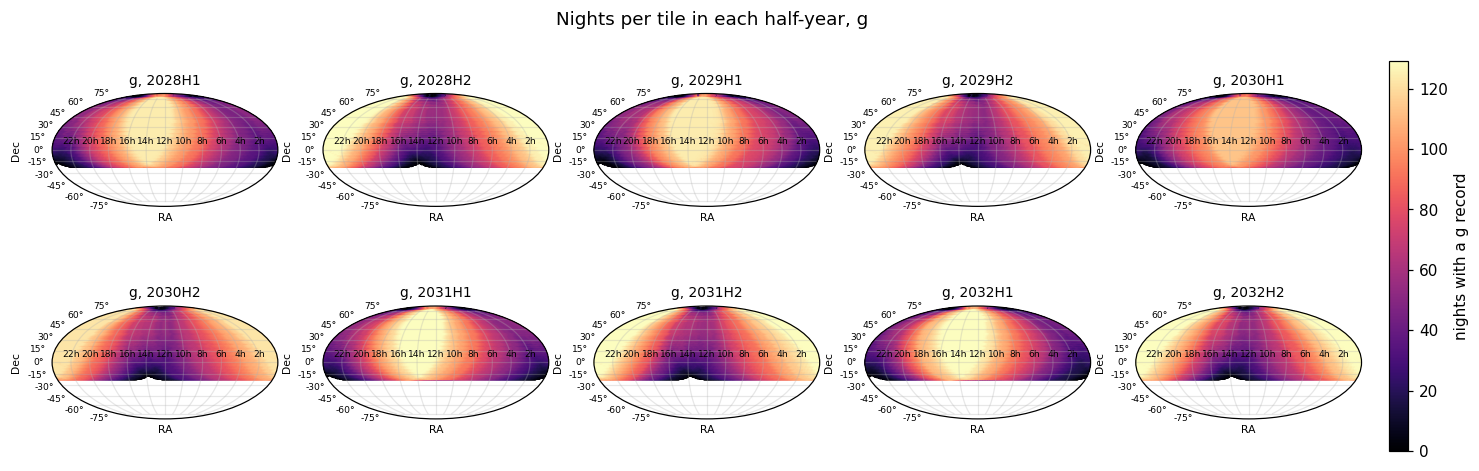

nights the survey observed in each half-year: {'2028H1': 124, '2028H2': 129, '2029H1': 124, '2029H2': 125, '2030H1': 113, '2030H2': 122, '2031H1': 129, '2031H2': 129, '2032H1': 129, '2032H2': 129}
most nights any g tile got in a half-year: {'2028H1': 124, '2028H2': 129, '2029H1': 124, '2029H2': 125, '2030H1': 113, '2030H2': 122, '2031H1': 129, '2031H2': 129, '2032H1': 129, '2032H2': 129}


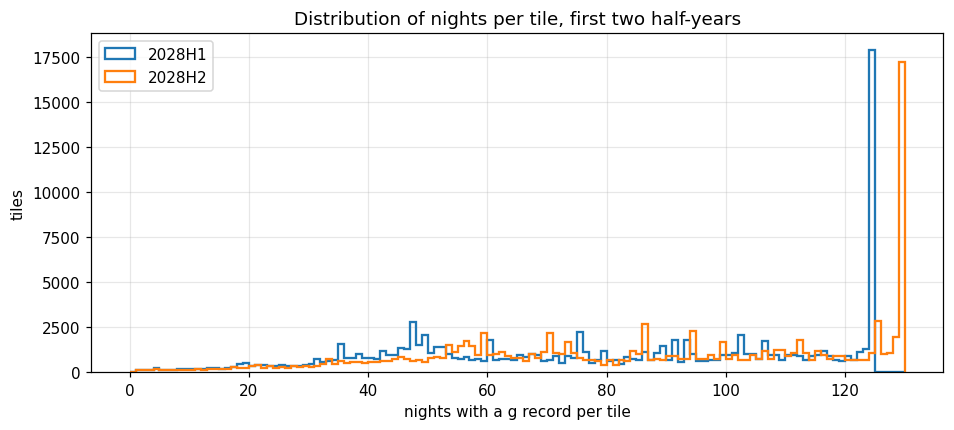

5 years: median 839 nights per tile in g, 10-90% 660-958


In [9]:
nmax = max(int(np.max(m["n_nights"])) for m in maps.values())
fig, axes = plt.subplots(2, 5, figsize=(16, 4.6), subplot_kw={"projection": "mollweide"})
for ax, p in zip(axes.flat, halves):
    sc = sky(ax, maps[p], maps[p]["n_nights"], f"g, {p}", "nights", cmap="magma", vmin=0, vmax=nmax)
fig.colorbar(sc, ax=axes, orientation="vertical", fraction=0.02, pad=0.02, label="nights with a g record")
fig.suptitle("Nights per tile in each half-year, g")
plt.show()

g_nights = ns[ns["band"] == "g"]
per_half = g_nights["date"].apply(lambda d: f"{d.year}H{1 if d.month <= 6 else 2}").value_counts().sort_index()
print("nights the survey observed in each half-year:", {k: int(v) for k, v in per_half.items()})
print("most nights any g tile got in a half-year:", {p: int(np.max(maps[p]["n_nights"])) for p in halves})

fig, ax = plt.subplots()
for p in (halves[0], halves[1]):
    ax.hist(maps[p]["n_nights"], bins=np.arange(0, nmax + 2), histtype="step", lw=1.5, label=p)
ax.set_xlabel("nights with a g record per tile"); ax.set_ylabel("tiles"); ax.legend()
ax.set_title("Distribution of nights per tile, first two half-years")
plt.show()
all_g = dm["g"]
print(f"5 years: median {np.median(all_g['n_nights']):.0f} nights per tile in g, 10-90% "
      f"{np.percentile(all_g['n_nights'], 10):.0f}-{np.percentile(all_g['n_nights'], 90):.0f}")

Over 5 years, a tile is seen in g/beta on a median of 839 nights (10-90%: 660-958). In a
half-year, the tiles that are up through the night in that season are seen on every night the survey ran: the peaks
of the histogram sit at 124 nights in 2028H1 and 129 in 2028H2, the survey's observed nights in
those half-years. Tiles near the Sun for most of a half-year are seen on a few tens of nights or fewer.

**Try it.** Divide `maps[p]["n_slots_60"]` by `maps[p]["n_nights"]` to get the mean number of 60-s slots per night
a tile gets. Tiles near the site's latitude stay in the footprint longest each night and should show the most.

## Step 7. Every exposure of one position

The rest of the tutorial works with one position at a time through the visit store. `run.visits(ra, dec)` returns an astropy
`Table` with one row per 60-s slot per covering OTA, sorted in time. A slot is one standard 60-s exposure, or
sixty 1-s frames in fast mode (bright time). A position in the overlap of two OTAs gets two rows for that slot.

In [13]:
RA, DEC = 223.878, 36.031
t = time.time()
vis = run.visits(RA, DEC)
print(f"{len(vis):,} slot rows in {time.time() - t:.2f} s")
fast = np.asarray(vis["exptime_s"]) == 1.0
print(f"{fast.mean():.1%} of the slots are sixty 1-s frames")
for b in run.bands:
    m = np.asarray(vis["band"]) == b
    print(f"{b:>4}: {m.sum():7,} slots ({(m & ~fast).sum():,} of 60 s, {(m & fast).sum():,} of 60 x 1 s)")
vis[:3]

291,942 slot rows in 0.06 s
11.8% of the slots are sixty 1-s frames
   g: 145,351 slots (128,296 of 60 s, 17,055 of 60 x 1 s)
 rho: 146,591 slots (129,285 of 60 s, 17,306 of 60 x 1 s)


mjd,band,tel_id,subarray,exptime_s,n_frames,sigma_bkg_e,throughput,airmass,field_angle,seeing_zenith,transparency,ratchet,night,slot
float64,str3,int64,int64,float64,int64,float64,float64,float64,float64,float64,float64,int64,int64,int64
61771.455555555556,rho,1088,3,60.0,1,45.675839484509176,0.7131278252500072,1.5776465832027704,0.9814338209335517,1.384225011921001,1.0,36,61770,0
61771.45625,rho,1088,3,60.0,1,45.675839484509176,0.7131278252500072,1.5776465832027704,0.9814338209335517,1.384225011921001,1.0,36,61770,1
61771.45694444444,rho,1088,3,60.0,1,45.675839484509176,0.7131278252500072,1.5776465832027704,0.9814338209335517,1.384225011921001,1.0,36,61770,2


Five years at this position give 291,942 slots, about half in each band, and 11.8% of
them in fast mode. The query should take well under a second.

The columns you will most likely use:

| column | meaning |
|---|---|
| `mjd` | start of the 60-s slot (MJD, UTC) |
| `band` | `g` (the beta band) or `rho` (fixed per OTA) |
| `exptime_s`, `n_frames` | 60 s × 1 frame or 1 s × 60 frames |
| `sigma_bkg_e` | background noise of one frame (electrons) |
| `throughput` | full-system throughput $T$ |
| `tel_id`, `subarray`, `ratchet`, `night` | which OTA, which mount, which 16-minute pointing, which night |
| `airmass`, `field_angle` (deg), `seeing_zenith` (arcsec), `transparency` | observing conditions |

`band=`, `mjd_min=` and `mjd_max=` select rows while the store is read, which is much faster than filtering a
5-year table.

## Step 8. Nights without data

`run.night_log(ra, dec)` has one row per night of the survey plan, including nights lost to weather. Its `status`
is `observed`, `weather` (the survey did not run), `moon` (the position was in an OTA field but within 1.5° of the
Moon, which the simulation masks; how operations will treat these data is not yet settled) or `not_in_footprint` (no OTA field reached it that night).

{'not_in_footprint': 313, 'observed': 940, 'weather': 574}


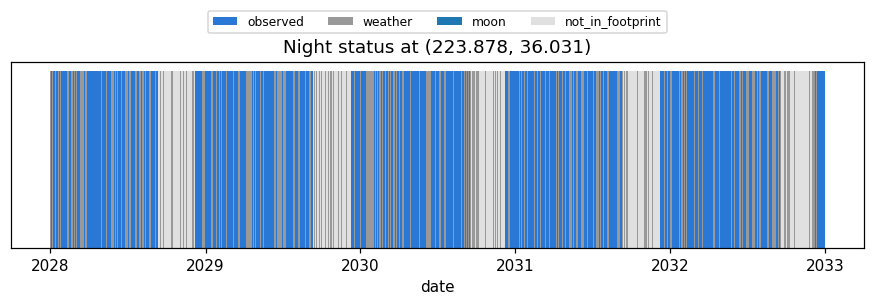

In [15]:
log = run.night_log(RA, DEC)
status, count = np.unique(np.asarray(log["status"]), return_counts=True)
print({str(s): int(k) for s, k in zip(status, count)})

fig, ax = plt.subplots(figsize=(10, 2.2))
colors = {"observed": "#2a78d6", "weather": "0.6", "moon": "#f2c14e", "not_in_footprint": "0.88"}
dates = Time(np.asarray(log["night"]), format="mjd").datetime
for s, col in colors.items():
    m = np.asarray(log["status"]) == s
    ax.bar(np.asarray(dates)[m], np.ones(m.sum()), width=1.0, color=col, label=s)
ax.set_yticks([]); ax.grid(False); ax.set_xlabel("date")
ax.set_title(f"Night status at ({RA}, {DEC})"); ax.legend(ncol=4, fontsize=8, loc="lower center", bbox_to_anchor=(0.5, 1.12))
plt.show()

Of the 1,827 planned nights, 940 observed this position, 574 were lost to weather,
and on 313 it was not in the nightly footprint (it was up only in daytime). The Moon never removed a
whole night here, but positions near the ecliptic will lose a few nights to it.

## Step 9. Photometric errors and depth per slot

For a source of AB magnitude $m$ in a frame of exposure $t$, the source gives $S = \mathrm{zp}_b\,10^{-0.4m}\,
\mathrm{QE}_b\,t\,T$ electrons, the variance is $\sigma_\mathrm{bkg}^2 + S$, and a 5 mmag floor is added in
quadrature to the magnitude error (measured on prototype data). `run.sigma_mag(vis, mag)`, `run.snr(vis, mag)` and `run.limit_mag(vis)` apply
this to a visit table. They describe one slot by default, so a fast-mode slot counts as its sixty 1-s frames
stacked. Pass `per="frame"` for a single frame.

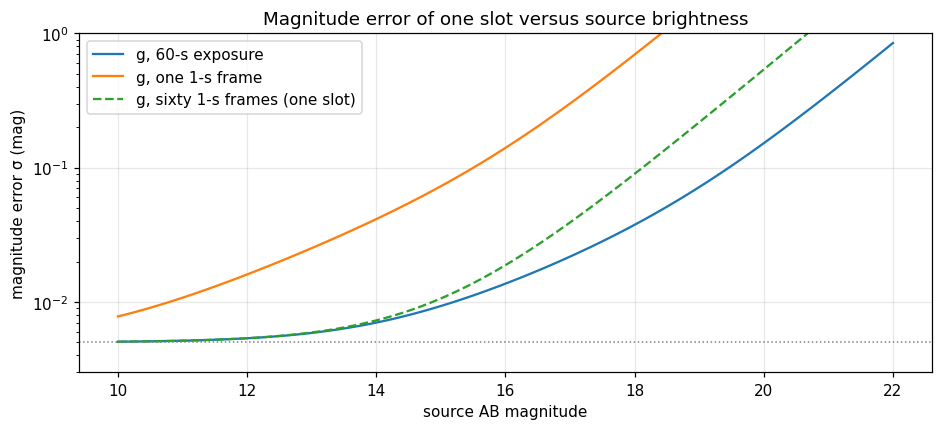

   g     60-s: 5σ limit median 20.43 mag, 10-90% 19.19-20.82
   g 60 x 1-s: 5σ limit median 18.83 mag, 10-90% 18.36-19.11
 rho     60-s: 5σ limit median 19.75 mag, 10-90% 19.00-20.13
 rho 60 x 1-s: 5σ limit median 18.70 mag, 10-90% 18.14-19.01


In [16]:
mags = np.linspace(10, 22, 121)
one_min = vis[(vis["band"] == "g") & ~fast][:1]
one_fast = vis[(vis["band"] == "g") & fast][:1]
fig, ax = plt.subplots()
ax.semilogy(mags, [run.sigma_mag(one_min, m)[0] for m in mags], label="g, 60-s exposure")
ax.semilogy(mags, [run.sigma_mag(one_fast, m, per="frame")[0] for m in mags], label="g, one 1-s frame")
ax.semilogy(mags, [run.sigma_mag(one_fast, m)[0] for m in mags], "--", label="g, sixty 1-s frames (one slot)")
ax.axhline(0.005, color="0.5", lw=1, ls=":")
ax.set_xlabel("source AB magnitude"); ax.set_ylabel("magnitude error σ (mag)"); ax.set_ylim(3e-3, 1)
ax.set_title("Magnitude error of one slot versus source brightness"); ax.legend()
plt.show()

lim = run.limit_mag(vis)
for b in run.bands:
    for name, sel in (("60-s", ~fast), ("60 x 1-s", fast)):
        l = lim[(np.asarray(vis["band"]) == b) & sel]
        print(f"{b:>4} {name:>8}: 5σ limit median {np.median(l):.2f} mag, 10-90% {np.percentile(l, 10):.2f}-{np.percentile(l, 90):.2f}")

A 60-s beta slot reaches a median 5σ limit of 20.43 mag. A fast-mode beta slot of sixty 1-s frames
reaches 18.83 mag if coadded, shallower because of the moonlit sky background and the read noise of sixty frames. The error curves flatten at the 5 mmag floor for bright sources. The 5 mmag floor comes from a limited prototype data set and may change as more data arrive.

## Step 10. Inject a model

A model is any function `model(mjd, band) -> AB mag`, ideally vectorised over arrays, where `band` is an array of strings.
`run.inject(vis, model, rng=...)` draws simulated photometry with one row per slot. It returns `mag_obs`, `mag_err`,
`detected` (5σ), `limit_mag` and fluxes in electrons and in microjansky (`flux_obs_ujy`; AB 23.9 = 1 μJy). The example below is
a toy RR Lyrae star model of mean beta mag = 16.5 and period 0.5672 d.

291,942 measurements; detected fraction 1.000


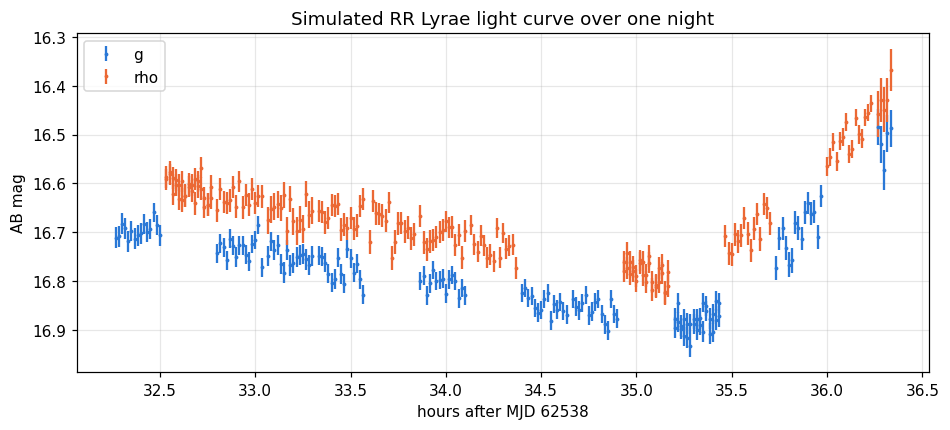

In [18]:
def rr_lyrae(mjd, band, P=0.5672, mean=16.5, amp=0.8):
    ph = (mjd / P) % 1.0
    shape = np.where(ph < 0.15, ph / 0.15, 1.0 - (ph - 0.15) / 0.85)
    return mean + amp / 2 - amp * shape + np.where(band == "rho", -0.1, 0.0)

lc = run.inject(vis, rr_lyrae, rng=np.random.default_rng(1))
print(f"{len(lc):,} measurements; detected fraction {lc['detected'].mean():.3f}")

night = np.unique(np.asarray(lc["night"]))[400]
x = lc[lc["night"] == night]
fig, ax = plt.subplots()
for b in run.bands:
    y = x[x["band"] == b]
    ax.errorbar((y["mjd"] - night) * 24, y["mag_obs"], y["mag_err"], fmt=".", ms=3, color=BAND_COLOR[b], label=b)
ax.invert_yaxis(); ax.set_xlabel(f"hours after MJD {night}"); ax.set_ylabel("AB mag")
ax.set_title("Simulated RR Lyrae light curve over one night"); ax.legend()
plt.show()

All 291,942 measurements detect the star. In one night the array follows most of a pulsation
cycle in both bands, one point per minute.

## Step 11. Bin and find the period

`bin_lightcurve(lc, by=...)` takes an inverse-variance mean of `flux_obs_ujy` per band, per `"night"`, per
`"ratchet"` or per bin of a given width in days. It uses every measurement, detected or not, so faint sources are
not biased bright. A periodogram of the 16-minute (per-pointing) beta bins recovers the period.

9,470 g ratchet bins; best period 0.56720 d (injected 0.5672 d)


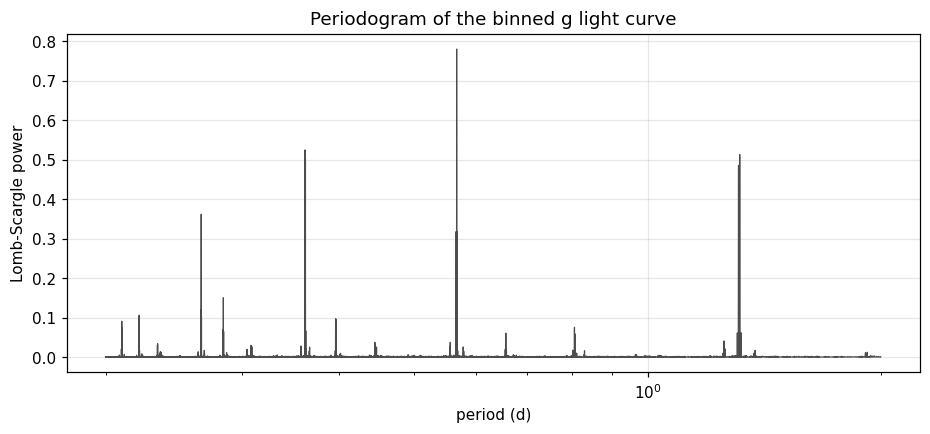

In [19]:
from astropy.timeseries import LombScargle

binned = bin_lightcurve(lc, by="ratchet")
g = binned[(binned["band"] == "g") & binned["detected"]]
freq, power = LombScargle(g["mjd"], g["mag"], g["mag_err"]).autopower(
    minimum_frequency=0.5, maximum_frequency=5, samples_per_peak=20
)
print(f"{len(g):,} g ratchet bins; best period {1 / freq[np.argmax(power)]:.5f} d (injected 0.5672 d)")

fig, ax = plt.subplots()
ax.plot(1 / freq, power, color="0.3", lw=0.8)
ax.set_xscale("log"); ax.set_xlabel("period (d)"); ax.set_ylabel("Lomb-Scargle power")
ax.set_title("Periodogram of the binned g light curve")
plt.show()

9,470 beta pointing bins give a best period of 0.56720 d, the injected value.

**Try it.** Set `mean=20.5` in `rr_lyrae`. Single slots then rarely reach 5σ, but the nightly bins
(`by="night"`) still detect the star and the periodogram still finds the period.

## Step 12. Exposure-dependent models

If a model has a parameter named `vis`, `inject` passes it the visit row of each evaluation, so the model can depend on the airmass (for colour terms), the seeing or the OTA itself. Here a beta = 18 star has a brighter neighbour 3″ away whose light leaks into the
aperture in proportion to the delivered seeing. The query covers only 60 nights of beta visits with `band`, `mjd_min` and
`mjd_max`.

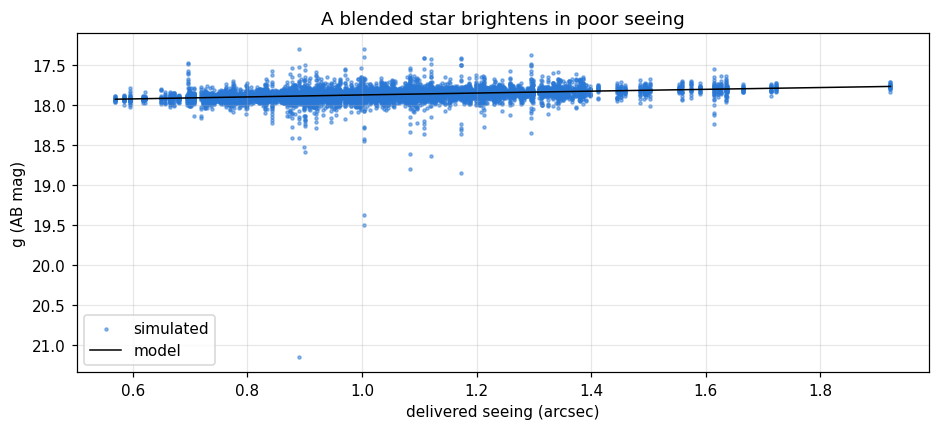

9,288 g slots; model spans 17.925 to 17.765 mag


In [21]:
def blended(mjd, band, vis):
    seeing = np.asarray(vis["seeing_zenith"]) * np.asarray(vis["airmass"]) ** 0.6   # arcsec
    leak = 0.05 * seeing                                                           # scale fraction of the neighbour's flux
    return -2.5 * np.log10(10 ** (-0.4 * 18.0) + leak * 10 ** (-0.4 * 17.0))

w = run.visits(RA, DEC, band="g", mjd_min=62200, mjd_max=62260)
lc_bl = run.inject(w, blended, rng=np.random.default_rng(5))
seeing = np.asarray(w["seeing_zenith"]) * np.asarray(w["airmass"]) ** 0.6
fig, ax = plt.subplots()
ax.scatter(seeing, lc_bl["mag_obs"], s=4, color=BAND_COLOR["g"], alpha=0.5, label="simulated")
o = np.argsort(seeing)
ax.plot(seeing[o], np.asarray(lc_bl["mag_true"])[o], color="k", lw=1, label="model")
ax.invert_yaxis(); ax.set_xlabel("delivered seeing (arcsec)"); ax.set_ylabel("g (AB mag)")
ax.set_title("A blended star brightens in poor seeing"); ax.legend()
plt.show()

print(f"{len(w):,} g slots; model spans {lc_bl['mag_true'].max():.3f} to {lc_bl['mag_true'].min():.3f} mag")

Over 9,288 beta slots the blended star varies from 17.925 to 17.765 mag with the seeing
alone. A variability search would need to separate this from real variability.

## Step 13. Argus bandpasses for sncosmo

Spectral models need the Argus filters. ArgusSim defines AB magnitudes through the filter transmission alone. The
optics and atmosphere are in the per-exposure throughput $T$, and the detector QE is the scalar
$\mathrm{QE}_b$. So, to avoid double-counting, the sncosmo bandpasses are the bare filter curves, taken from the files ArgusSim uses.

In [22]:
import sncosmo
from argus_sim.throughput import SystemThroughput

tp = SystemThroughput()
wave_aa = tp.wav.to("AA").value
for b in ("g", "rho"):
    T = np.asarray(tp.filt_wav[b])
    nz = np.flatnonzero(T > 1e-3 * T.max())              # sncosmo wants the curve trimmed to where it transmits
    s = slice(max(nz[0] - 1, 0), nz[-1] + 2)
    sncosmo.register(sncosmo.Bandpass(wave_aa[s], T[s], name=f"argus::{b}"), force=True)
    bp = sncosmo.get_bandpass(f"argus::{b}")
    print(f"argus::{b:<3}  {bp.minwave():.0f}-{bp.maxwave():.0f} Å, effective {bp.wave_eff:.0f} Å")

argus::g    3610-5285 Å, effective 4445 Å
argus::rho  5580-8270 Å, effective 6925 Å


To check the convention, a flat 3631 Jy source (AB magnitude 0) through these bandpasses, times the per-telescope
collecting area, should give the run's own zero-point photon rate.

In [23]:
import astropy.constants as const
import astropy.units as u
from argus_sim import c as argus_config

area_cm2 = u.Quantity(argus_config.telescope.collecting_area).to_value(u.cm**2)
for b in ("g", "rho"):
    bp = sncosmo.get_bandpass(f"argus::{b}")
    w = bp.wave                                            # Å
    flam = 3631e-23 * const.c.to_value("AA/s") / w**2      # erg/s/cm²/Å
    photons = np.trapezoid(flam * bp(w) * w / (const.h.cgs.value * const.c.to_value("AA/s")), w) * area_cm2
    print(f"{b:>4}: sncosmo {photons:.4e} photons/s, run zero point {run.zeropoints[b]['zp_photons_per_sec']:.4e}, "
          f"ratio {photons / run.zeropoints[b]['zp_photons_per_sec']:.4f}")

   g: sncosmo 7.9965e+08 photons/s, run zero point 7.9961e+08, ratio 1.0001
 rho: sncosmo 8.3670e+08 photons/s, run zero point 8.3665e+08, ratio 1.0001


The ratios are 1.0001 in beta and 1.0001 in rho, so sncosmo magnitudes through
these bandpasses match ArgusSim AB magnitudes. A small wrapper turns any sncosmo `Model` into an `inject` model; outside
the model's time range the source has no flux.

In [24]:
ARGUS_BAND = {"g": "argus::g", "rho": "argus::rho"}

def from_sncosmo(model):
    def f(mjd, band):
        mjd, band = np.asarray(mjd, float), np.asarray(band)
        out = np.full(mjd.shape, np.inf)
        inside = (mjd > model.mintime()) & (mjd < model.maxtime())
        for b, name in ARGUS_BAND.items():
            m = inside & (band == b)
            if m.any():
                flux = model.bandflux(name, mjd[m], zp=0.0, zpsys="ab")   # zp 0 AB: mag = -2.5 log10(flux)
                with np.errstate(divide="ignore", invalid="ignore"):
                    out[m] = np.where(flux > 0, -2.5 * np.log10(flux), np.inf)
        return out
    return f

## Step 14. A type Ia supernova

A normal SN Ia (SALT2, Guy+2007; $x_1 = 0$, $c = 0$, $M_B = -19.3$) at $z = 0.04$. The query covers only the event's
window, and the result is binned per night.

9,306 slots in the window, 7,142 single-slot detections, 86 detected night bins


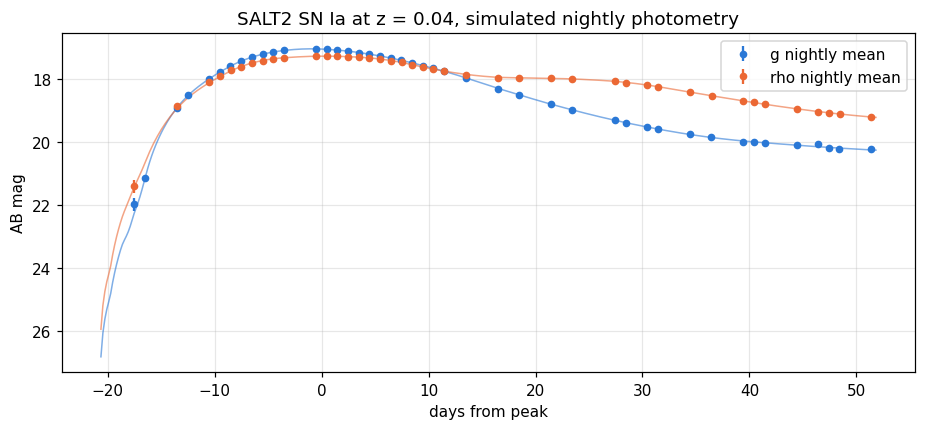

In [25]:
sn = sncosmo.Model("salt2")
sn.set(z=0.04, t0=62505.0, x1=0.0, c=0.0)
sn.set_source_peakabsmag(-19.3, "bessellb", "ab")

w = run.visits(RA, DEC, mjd_min=sn.mintime(), mjd_max=sn.maxtime())
lc_sn = run.inject(w, from_sncosmo(sn), rng=np.random.default_rng(7))
nightly = bin_lightcurve(lc_sn, by="night")
print(f"{len(w):,} slots in the window, {lc_sn['detected'].sum():,} single-slot detections, "
      f"{nightly['detected'].sum()} detected night bins")

fig, ax = plt.subplots()
tt = np.linspace(sn.mintime(), sn.maxtime(), 400)
for b in run.bands:
    y = nightly[(nightly["band"] == b) & nightly["detected"]]
    ax.errorbar(y["mjd"] - sn.get("t0"), y["mag"], y["mag_err"], fmt="o", ms=4, color=BAND_COLOR[b],
                label=f"{b} nightly mean")
    ax.plot(tt - sn.get("t0"), from_sncosmo(sn)(tt, np.full(tt.size, b)), color=BAND_COLOR[b], lw=1, alpha=0.6)
ax.invert_yaxis(); ax.set_xlabel("days from peak"); ax.set_ylabel("AB mag")
ax.set_title("SALT2 SN Ia at z = 0.04, simulated nightly photometry"); ax.legend()
plt.show()

The window holds 9,306 slots. 7,142 single slots detect the supernova, and 86
night bins do. The nightly means follow the model into the tail, where single slots fall below the limit.

## Step 15. A kilonova with redback

redback (Sarin+2024) models can return an sncosmo source (`output_format="sncosmo_source"`), so the same wrapper works. The example is
a lanthanide-poor kilonova ($\kappa = 0.5$ cm² g⁻¹) at 40 Mpc. A lanthanide-rich one ($\kappa$ of 3 to 10) is
several magnitudes fainter in beta.

2,732 slots, 448 detections on 2 nights; first detection 28.0 h after merger


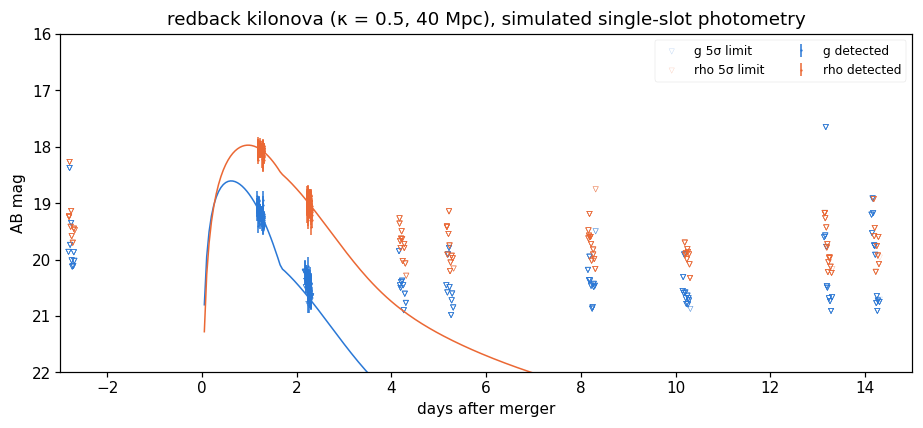

In [26]:
from redback.transient_models.kilonova_models import one_component_kilonova_model

plt.rcParams["text.usetex"] = False   # importing redback switches matplotlib to LaTeX text rendering

t_merger = 62531.2
phases = np.linspace(0.05, 15, 300)
src = one_component_kilonova_model(phases, redshift=0.009, mej=0.03, vej=0.25, kappa=0.5,
                                   output_format="sncosmo_source")
kn = sncosmo.Model(source=src)
kn.set(t0=t_merger)          # redback phases are days after merger

w = run.visits(RA, DEC, mjd_min=t_merger - 3, mjd_max=t_merger + 15)
lc_kn = run.inject(w, from_sncosmo(kn), rng=np.random.default_rng(3))
det_nights = np.unique(np.asarray(lc_kn["night"])[np.asarray(lc_kn["detected"])])
print(f"{len(w):,} slots, {lc_kn['detected'].sum():,} detections on {len(det_nights)} nights; "
      f"first detection {(lc_kn['mjd'][lc_kn['detected']].min() - t_merger) * 24:.1f} h after merger")

fig, ax = plt.subplots()
tt = np.linspace(t_merger + 0.05, t_merger + 15, 300)
for b in run.bands:
    y = lc_kn[lc_kn["band"] == b]
    d, n = y[y["detected"]], y[~y["detected"]]
    ax.errorbar(d["mjd"] - t_merger, d["mag_obs"], d["mag_err"], fmt=".", ms=3, color=BAND_COLOR[b], label=f"{b} detected")
    ax.scatter(n["mjd"] - t_merger, n["limit_mag"], marker="v", s=12, facecolors="none", edgecolors=BAND_COLOR[b],
               alpha=0.35, label=f"{b} 5σ limit")
    ax.plot(tt - t_merger, from_sncosmo(kn)(tt, np.full(tt.size, b)), color=BAND_COLOR[b], lw=1)
ax.invert_yaxis(); ax.set_ylim(22, 16); ax.set_xlim(-3, 15)
ax.set_xlabel("days after merger"); ax.set_ylabel("AB mag"); ax.legend(ncol=2, fontsize=8)
ax.set_title("redback kilonova (κ = 0.5, 40 Mpc), simulated single-slot photometry")
plt.show()

The kilonova is detected in 448 slots on 2 nights, first 28.0 h after the
merger.

**Try it.** Move `t_merger` by 6 to 12 hours. When the merger falls while the position is below the horizon or the
night is lost to weather, the first detection comes a day or more later. 

## Step 16. Many sources

For many positions, query one position at a time with `mjd_min` and `mjd_max` set to the event's window, and reduce
each result before the next. A full 5-year query is about 290,000 rows at the position of Step 7, so one table for hundreds of
full positions would take tens of GB of memory. The cell below places 300 SNe Ia at random positions and peak times in 2030 and
counts how many are detected on at least three nights before peak.

300 positions queried and injected in 26 s
211 observed in the 20 days before peak; 207 detected on at least 3 nights


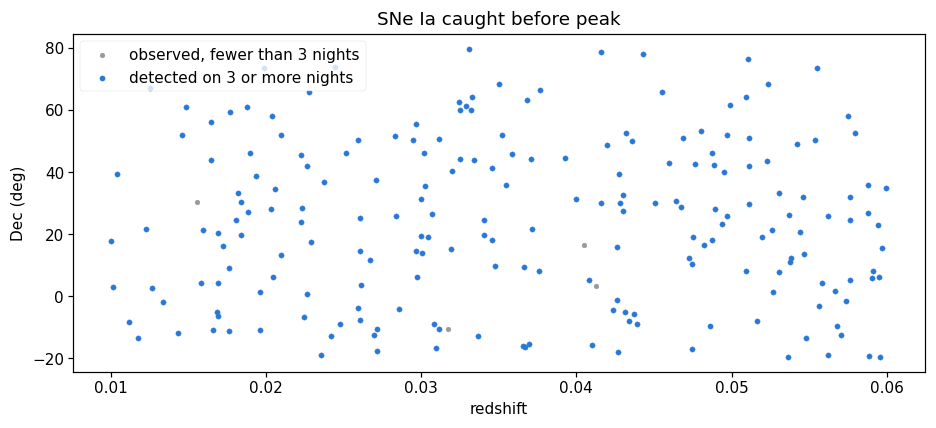

notebook run time so far 43.2 min


In [28]:
rng = np.random.default_rng(42)
n = 300
ra = rng.uniform(0, 360, n)
dec = np.degrees(np.arcsin(rng.uniform(np.sin(np.radians(-20)), np.sin(np.radians(80)), n)))
t0 = rng.uniform(Time("2030-01-01").mjd, Time("2031-01-01").mjd, n)
z = rng.uniform(0.01, 0.06, n)

observed = np.zeros(n, bool)
early = np.zeros(n, bool)
model = sncosmo.Model("salt2")
t = time.time()
for i in range(n):
    v = run.visits(ra[i], dec[i], mjd_min=t0[i] - 20, mjd_max=t0[i])
    observed[i] = len(v) > 0
    if len(v) == 0:
        continue
    model.set(z=z[i], t0=t0[i], x1=0.0, c=0.0)
    model.set_source_peakabsmag(-19.3, "bessellb", "ab")
    out = run.inject(v, from_sncosmo(model), rng=rng)
    early[i] = len(np.unique(np.asarray(out["night"])[np.asarray(out["detected"])])) >= 3
print(f"{n} positions queried and injected in {time.time() - t:.0f} s")
print(f"{observed.sum()} observed in the 20 days before peak; {early.sum()} detected on at least 3 nights")

fig, ax = plt.subplots()
ax.scatter(z[observed & ~early], dec[observed & ~early], s=10, color="0.6", label="observed, fewer than 3 nights")
ax.scatter(z[early], dec[early], s=12, color="#2a78d6", label="detected on 3 or more nights")
ax.set_xlabel("redshift"); ax.set_ylabel("Dec (deg)"); ax.set_title("SNe Ia caught before peak"); ax.legend()
plt.show()
print(f"notebook run time so far {(time.time() - T_START) / 60:.1f} min")

Of 300 supernovae, 211 were observed in the 20 days before peak and 207 were
detected on at least three nights. The query and injection should take about half a minute for all 300.

**Try it.** Change the window to `t0[i] - 5` to `t0[i] + 30` and count detections after peak instead.

## Disclaimers

The PSF follows the delivered image-quality specification, an EE50 diameter of 3.0 pixels at the field corners, so
the simulated depths are conservative. The weather and seeing models draw from long-term statistics for a dark site
and do not reproduce any particular night. The results are intended for science modelling and survey planning and are
not performance guarantees for the instrument.

## Where next

- `notebooks/tutorial_depth_calculation.ipynb` shows how the depth of one exposure comes from the sky background
  and instrument models.
- The docstrings of `argus_sim.lightcurve` document every option of the light-curve API: `help(run.visits)`,
  `help(run.depth_map)`, `help(run.night_log)`, `help(run.inject)` and `help(bin_lightcurve)`.